In [3]:
import json
from pathlib import Path

import jax
import flax.nnx as nnx
import orbax
from orbax import checkpoint

from model import MiniGPT

%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np

import jax.numpy as jnp

import matplotlib.pyplot as plt

import tiktoken

import pandas as pd

In [19]:
import importlib
import model

importlib.reload(model)
MiniGPT = model.MiniGPT

In [2]:
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
PROMPTS = [
    "Once upon a time a big bear",
    "There was a little girl named Lily",
    "One day Tom went into the forest",
    "The little dog was very afraid",
]

In [5]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=1.0,
    seed=42
):
    tokens = tokenizer.encode(prompt)
    key = jax.random.PRNGKey(seed)

    eos_token = tokenizer.encode(
        "<|endoftext|>",
        allowed_special={"<|endoftext|>"}
    )[0]

    for _ in range(max_new_tokens):

        context = tokens[-model.maxlen:]
        actual_len = len(context)

        if actual_len < model.maxlen:
            context = context + [0] * (model.maxlen - actual_len)

        context_array = jnp.asarray(
            context,
            dtype=jnp.int32
        )[None, :]

        logits = model(context_array)

        next_token_logits = logits[
            0,
            actual_len - 1,
            :
        ]

        # Temperature
        next_token_logits = next_token_logits / temperature

        key, subkey = jax.random.split(key)

        next_token = int(
            jax.random.categorical(
                subkey,
                next_token_logits
            )
        )

        if next_token == eos_token:
            break

        tokens.append(next_token)

    return tokenizer.decode(tokens)

In [ ]:
# Reload this module after changing model or checkpoint-loading code.
import evaluation
importlib.reload(evaluation)
load_experiment = evaluation.load_experiment


# 10K stories

In [ ]:
EXPERIMENT = "baseline_10k_256"
model, config, metrics = load_experiment(EXPERIMENT)


In [ ]:
# Architecture is reconstructed by load_experiment, including older checkpoints.


In [ ]:
# To inspect an epoch checkpoint: load_experiment(EXPERIMENT, checkpoint="epoch_001")


In [9]:
print("Model maxlen:", model.maxlen)
print("Devices:", jax.devices())

Model maxlen: 256
Devices: [CpuDevice(id=0)]


In [ ]:
steps = np.arange(1, 50 * len(metrics["train_loss"]) + 1, 50)
losses = metrics["train_loss"]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses)

plt.title(f"Training loss — {EXPERIMENT}")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

In [23]:
for prompt in PROMPTS:
    print("=" * 80)
    print(f"PROMPT: {prompt}\n")

    text = generate_text(
        model,
        tokenizer,
        prompt,
        max_new_tokens=100,
        temperature=0.8,
        seed=42
    )

    print(text)
    print()

PROMPT: Once upon a time a big bear

Once upon a time a big bear and friends. He was playing in a girl who loved to the ball. Inside that David was a rain and saw it.
One across a race,, it was very bit in the baby safe. They went to take a cage, "Yes, "
The voice were so happy to eat was a little boy replied about the nest.
One to get very feel special flying,”
When they played on, "It was too and said, "Sorry, "I want to

PROMPT: There was a little girl named Lily

There was a little girl named Lilymy. She stared for her momucky. One day, Lily felt excited to her momama one day, she liked to her mom across a books. She was special you a new mommy. Lily was very strange. Her room, she ran to her mommy, she could her mom said she took a bigap about her nest.
When she walked away together. His mommy didn't find her high on her great hair.
M said she told her looking to warm!" Everyone

PROMPT: One day Tom went into the forest

One day Tom went into the forest and friends. He was playing

# 25K stories

In [34]:
EXPERIMENT = "baseline_25k_256"
model, config, metrics = load_experiment(EXPERIMENT)

In [38]:
metrics_df = pd.DataFrame.from_dict(metrics)
metrics_df.head()

,epoch,step,loss,learning_rate
0,1,50,10.596505,0.000064
1,1,100,8.095605,0.000128
2,1,150,6.224899,0.000192
3,1,200,5.951338,0.000256
4,1,250,5.838405,0.000300


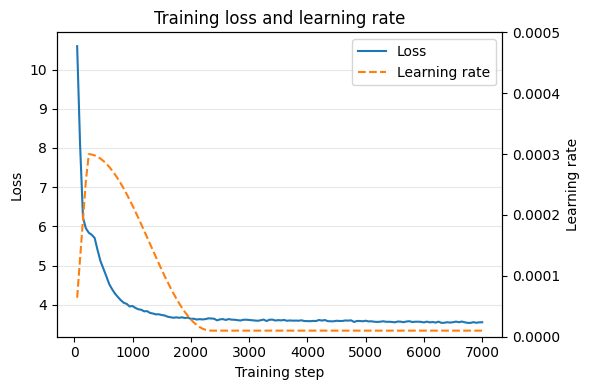

In [63]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Loss
loss_line, = ax1.plot(metrics_df["step"], metrics_df["loss"], label="Loss")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")
plt.grid(axis="y", alpha=0.3)

# Learning rate
ax2 = ax1.twinx()
ax2.set_ylim(0, 0.00050)
lr_line, = ax2.plot(
    metrics_df["step"], metrics_df["learning_rate"],
    linestyle="--",
    label="Learning rate",
    color="tab:orange"
)
ax2.set_ylabel("Learning rate")

# Combined legend
ax1.legend(
    handles=[loss_line, lr_line],
    loc="upper right"
)

plt.title("Training loss and learning rate")
fig.tight_layout()
plt.show()

In [53]:
for prompt in PROMPTS:
    print("=" * 80)
    print(f"PROMPT: {prompt}\n")

    text = generate_text(
        model,
        tokenizer,
        prompt,
        max_new_tokens=100,
        temperature=0.8,
        seed=42
    )

    print(text)
    print()

PROMPT: Once upon a time a big bear

Once upon a time a big bear was friends. He was playing in a big tree with his backyard. The boat that was very curious. The little boy stping in the jungle.
One day, the sun decided to learn a big man. The bird started it was scared. He had so too. 
The cat was gentle. She grabbed him and he could see trying for a cat. It was flying in the boat. He was high on, he could not covered and too.

PROMPT: There was a little girl named Lily

There was a little girl named Lily. She was very very wrong. She wanted to take her mom and she clean her dad. Her mom said, "Mommy. Can I can't find it. Do you okay, she should make Lily.
She started it, she got an wish. Lily slipped on her toy and she was a little girl. She was very useful. She looked together. She met some things in the doll. The bowl and said, she was covered her toys.

PROMPT: One day Tom went into the forest

One day Tom went into the forest. It was very cute and wanted to do. One day, they saw 

# 25K stories with LayerNorm

In [17]:
EXPERIMENT = "baseline_norm_25k_256"
model, config, metrics = load_experiment(EXPERIMENT)

/Users/alisa/Work/Learning JAX/experiments/baseline_norm_25k_256/checkpoints/final


/Users/alisa/miniconda3/envs/mini-gpt/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:952: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [13]:
metrics_df = pd.DataFrame.from_dict(metrics)
metrics_df.head()

,epoch,step,loss,learning_rate
0,1,50,11.363384,0.000064
1,1,100,8.561720,0.000128
2,1,150,6.478217,0.000192
3,1,200,5.920821,0.000256
4,1,250,5.653484,0.000300


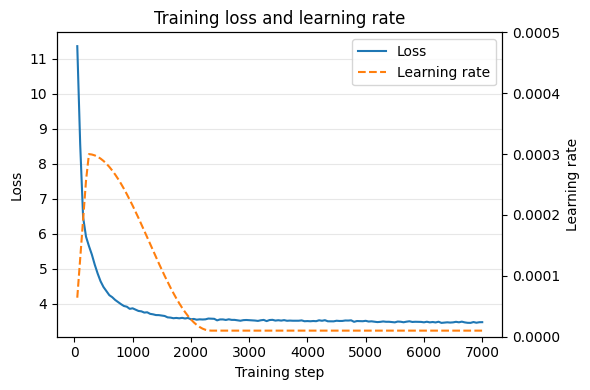

In [14]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Loss
loss_line, = ax1.plot(metrics_df["step"], metrics_df["loss"], label="Loss")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")
plt.grid(axis="y", alpha=0.3)

# Learning rate
ax2 = ax1.twinx()
ax2.set_ylim(0, 0.00050)
lr_line, = ax2.plot(
    metrics_df["step"], metrics_df["learning_rate"],
    linestyle="--",
    label="Learning rate",
    color="tab:orange"
)
ax2.set_ylabel("Learning rate")

# Combined legend
ax1.legend(
    handles=[loss_line, lr_line],
    loc="upper right"
)

plt.title("Training loss and learning rate")
fig.tight_layout()
plt.show()

In [18]:
for prompt in PROMPTS:
    print("=" * 80)
    print(f"PROMPT: {prompt}\n")

    text = generate_text(
        model,
        tokenizer,
        prompt,
        max_new_tokens=100,
        temperature=0.8,
        seed=42
    )

    print(text)
    print()

PROMPT: Once upon a time a big bear

Once upon a time a big bear was. He wanted to give up. He was a big smile and he was very so he found a little girl. The cat came across a race in the rabbit. He was so excited. He was very angry and he started to the monkey on an old toy. The cat on his sweets and was very sad. The cat was very useful bit a big landscape. It met some things and didn't like it. The fish very sad.
The little boy made its new friend. He was

PROMPT: There was a little girl named Lily

There was a little girl named Lily was. She wanted to play with her girl who went to the ingredients. Inside that was very excited. She saw her destination and she started to be afraid, it was going to clean or. She was excited and started to drive it, she would an cookie.
When she could try to eat it. She would get it was not see her ones for her. She met some things and didn't seen. She told her, she was too excited to be fun. She was so she was

PROMPT: One day Tom went into the fores

In [20]:
EXPERIMENT = "ffn_25k_256"
model, config, metrics = load_experiment(EXPERIMENT)

/Users/alisa/Work/Learning JAX/experiments/ffn_25k_256/checkpoints/final


In [40]:
def exponential_moving_average(values, alpha=0.15):
    smoothed = [values[0]]

    for value in values[1:]:
        smoothed.append(
            alpha * value + (1 - alpha) * smoothed[-1]
        )

    return np.array(smoothed)

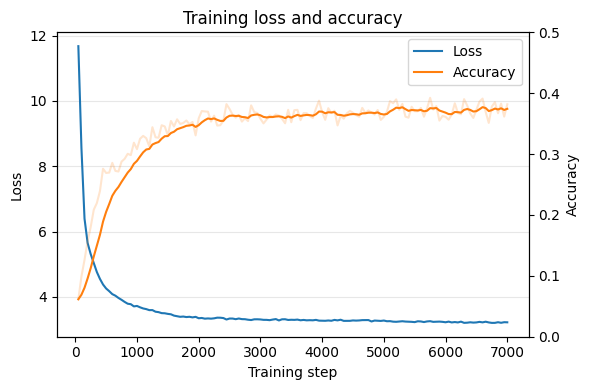

In [45]:
metrics_df = pd.DataFrame.from_dict(metrics)

fig, ax1 = plt.subplots(figsize=(6, 4))

# Loss
loss_line, = ax1.plot(metrics_df["step"], metrics_df["loss"], label="Loss")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")
plt.grid(axis="y", alpha=0.3)

# Learning rate
ax2 = ax1.twinx()
ax2.set_ylim(0, 0.5)
ax2.plot(metrics_df["step"], metrics_df["accuracy"], color="tab:orange", alpha=0.2)
accuracy_smooth = exponential_moving_average(metrics_df["accuracy"], alpha=0.2)
lr_line, = ax2.plot(
    metrics_df["step"], accuracy_smooth,
    linestyle="-",
    label="Accuracy",
    color="tab:orange"
)
ax2.set_ylabel("Accuracy")

# Combined legend
ax1.legend(
    handles=[loss_line, lr_line],
    loc="upper right"
)

plt.title("Training loss and accuracy")
fig.tight_layout()
plt.show()

In [39]:
for prompt in PROMPTS:
    print("=" * 80)
    print(f"PROMPT: {prompt}\n")

    text = generate_text(
        model,
        tokenizer,
        prompt,
        max_new_tokens=100,
        temperature=0.8,
        seed=42
    )

    print(text)
    print()

PROMPT: Once upon a time a big bear

Once upon a time a big bear was a kitten who was very cheerful. She loved to eat the ingredients and clean that was very special. One day he decided to go across a race. He looked hanging and he decided to a mark on it.
The orange cage, the other side of the monster came to the lake and said was a little girl called out. She was trying to eat the frog but the wrap Daisy was an adventure. The boy was so surprised again.
The little girl was so happy that she would never

PROMPT: There was a little girl named Lily

There was a little girl named Lily was very happy. One day, a girl called it was her and it was her and her friends. She saw her favourite flower and started to cry. She ran over to the counter, but she accidentally started to carry her wrist. She started on an iged around and put on her feet. 
Lily was about her tight. She said to get very sad. She put her eyes and went closer. She said "Don't worry, I don't worry. You can't see

PROMPT: On

## Compare the three architecture experiments

1. Attention + pre-LayerNorm (no FFN, no final norm).
2. Add the GELU FFN; compare with experiment 1.
3. Add final LayerNorm; compare with experiment 2.

Use identical data, split, model width/depth, training steps, and sampling settings.
The FFN adds parameters, so its effect includes extra model capacity. Perplexity
is exp(cross-entropy), not an independent signal. One seed is an educational
comparison, rather than proof of a universal improvement.

Run this section independently after the imports above; the historical sections
are optional. Missing results are skipped so partial sets of completed runs can
be inspected.


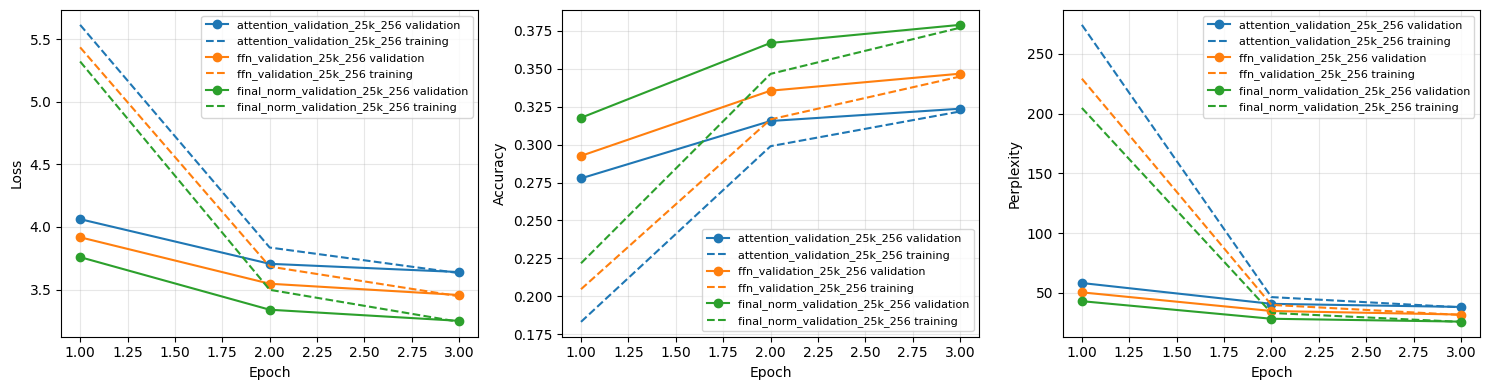

,experiment,epoch,step,train_loss,train_accuracy,train_perplexity,train_tokens,val_loss,val_accuracy,val_perplexity,val_tokens
0,attention_validation_25k_256,3.0,2109.0,3.631721,0.321796,37.777782,4314984.0,3.640208,0.323601,38.099768,478691.0
1,ffn_validation_25k_256,3.0,2109.0,3.446445,0.344807,31.388605,4314984.0,3.456980,0.346685,31.721035,478691.0
2,final_norm_validation_25k_256,3.0,2109.0,3.242422,0.376984,25.595641,4314984.0,3.250503,0.378852,25.803326,478691.0


In [46]:
EXPERIMENTS = [
    "attention_validation_25k_256",
    "ffn_validation_25k_256",
    "final_norm_validation_25k_256",
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison_rows = []
for name in EXPERIMENTS:
    metrics_path = Path("experiments") / name / "epoch_metrics.json"
    if not metrics_path.exists():
        print(f"{name}: no epoch results yet")
        continue
    frame = pd.DataFrame(json.loads(metrics_path.read_text()))
    comparison_rows.append({"experiment": name, **frame.iloc[-1].to_dict()})
    for ax, metric in zip(axes, ["loss", "accuracy", "perplexity"]):
        line, = ax.plot(frame["epoch"], frame[f"val_{metric}"], marker="o", label=f"{name} validation")
        ax.plot(frame["epoch"], frame[f"train_{metric}"], linestyle="--", color=line.get_color(), label=f"{name} training")
        ax.set(xlabel="Epoch", ylabel=metric.capitalize())
        ax.grid(alpha=0.3)
for ax in axes:
    if ax.lines:
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
display(pd.DataFrame(comparison_rows))


In [50]:
  import evaluation
  importlib.reload(evaluation)
  load_experiment = evaluation.load_experiment

In [51]:
# Each experiment is restored using its own recorded architecture.
# Use the same prompts, temperature, and generation seed for all variants.
for name in EXPERIMENTS:
    checkpoint_path = Path("experiments") / name / "checkpoints" / "final"
    if not checkpoint_path.exists():
        print(f"{name}: final checkpoint not available yet")
        continue
    loaded_model, loaded_config, _ = load_experiment(name)
    loaded_tokenizer = tiktoken.get_encoding(loaded_config["tokenizer"])
    print(f"\nEXPERIMENT: {name}")
    for prompt in PROMPTS:
        print(f"\nPROMPT: {prompt}")
        print(generate_text(loaded_model, loaded_tokenizer, prompt,
                            max_new_tokens=100, temperature=0.8, seed=42))
    del loaded_model



EXPERIMENT: attention_validation_25k_256

PROMPT: Once upon a time a big bear
Once upon a time a big bear was friends, there. She wanted to the park and his friends. One day that was very tired. The little girl stelly and started to be lots of all was very happy. 
When they walked, Jane found a cage, she ran in the toy. The cat on the cat was so happy. She wanted to show the lock, the cake.
The old man felt so happy to visit first. She said, "Oh, can do your friend, looking for you!" The

PROMPT: There was a little girl named Lily
There was a little girl named Lily was. She had a big, playing in the park with her. She was that was very excited. She saw it and she had very sad.
One day, she could not want to mark. Lily went to take a cage, she could an old lady. She thought it was so she was a little girl. She was not see her friends for Tommy.
The little toy and didn't find her high on her. She was too safe too. She thought she was warm and she

PROMPT: One day Tom went into the fores